In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import StratifiedKFold

In [2]:
df = pd.read_csv("./raw_data/motor_cortex.csv")

In [3]:
print(df)

       trial_id  cell_id brain_area       window  spike_count  direction  \
0             0        0        PMd  instruction          0.0          3   
1             0        0        PMd           go          8.0          3   
2             0        1        PMd  instruction          9.0          3   
3             0        1        PMd           go         23.0          3   
4             0        2        PMd  instruction          3.0          3   
...         ...      ...        ...          ...          ...        ...   
45183       157      140         MI           go         16.0          8   
45184       157      141         MI  instruction          0.0          8   
45185       157      141         MI           go          2.0          8   
45186       157      142         MI  instruction          4.0          8   
45187       157      142         MI           go          7.0          8   

       instruction_time      go_time  
0             14.852567    16.308333  
1        

In [4]:
df.isna().sum()

trial_id            0
cell_id             0
brain_area          0
window              0
spike_count         0
direction           0
instruction_time    0
go_time             0
dtype: int64

In [5]:
df['angle_rad'] = 2 * np.pi * (df['direction'] - 1) / 8
df['mx'] = np.cos(df['angle_rad'])
df['my'] = np.sin(df['angle_rad'])

<Axes: >

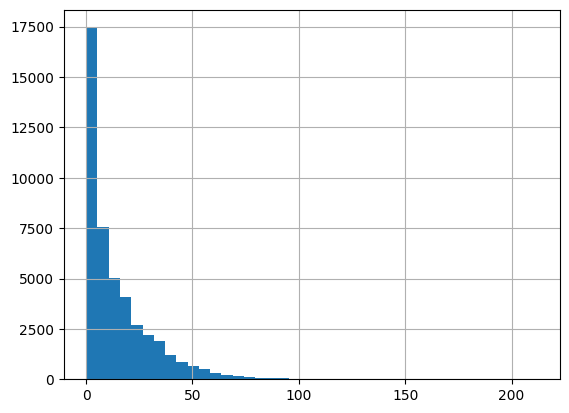

In [6]:
df['spike_count'].hist(bins=40)

In [7]:
df.groupby('brain_area')['cell_id'].nunique()

brain_area
MI     78
PMd    65
Name: cell_id, dtype: int64

In [8]:
df['direction'].value_counts().sort_index()

1    4004
2    3432
3    6292
4    5720
5    7150
6    6864
7    6864
8    4862
Name: direction, dtype: int64

In [9]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45188 entries, 0 to 45187
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   trial_id          45188 non-null  int64  
 1   cell_id           45188 non-null  int64  
 2   brain_area        45188 non-null  object 
 3   window            45188 non-null  object 
 4   spike_count       45188 non-null  float64
 5   direction         45188 non-null  int64  
 6   instruction_time  45188 non-null  float64
 7   go_time           45188 non-null  float64
 8   angle_rad         45188 non-null  float64
 9   mx                45188 non-null  float64
 10  my                45188 non-null  float64
dtypes: float64(6), int64(3), object(2)
memory usage: 3.8+ MB


,trial_id,cell_id,brain_area,window,spike_count,direction,instruction_time,go_time,angle_rad,mx,my
0,0,0,PMd,instruction,0.0,3,14.852567,16.308333,1.570796,6.123234e-17,1.0
1,0,0,PMd,go,8.0,3,14.852567,16.308333,1.570796,6.123234e-17,1.0
2,0,1,PMd,instruction,9.0,3,14.852567,16.308333,1.570796,6.123234e-17,1.0
3,0,1,PMd,go,23.0,3,14.852567,16.308333,1.570796,6.123234e-17,1.0
4,0,2,PMd,instruction,3.0,3,14.852567,16.308333,1.570796,6.123234e-17,1.0


In [10]:
## Building trial run + mapping out neuron matrices for different brain_areas

def build_matrix(df, brain_area, window):
    subset = df[(df['brain_area'] == brain_area) & (df['window'] == window)]
    
    ## rows = trials, columns = neurons
    mat = subset.pivot(index='trial_id', columns='cell_id', values='spike_count')
    
    mat = mat.fillna(0)
    
    return mat

In [11]:
## Building all four matrices.

m_pmd_instr = build_matrix(df, "PMd", "instruction")
m_pmd_go = build_matrix(df, "PMd", "go")
m_mi_instr = build_matrix(df, "MI", "instruction")
m_mi_go = build_matrix(df, "MI", "go")

In [12]:
print(m_pmd_instr.shape)
print(m_pmd_go.shape)
print(m_mi_instr.shape)
print(m_mi_go.shape)

(158, 65)
(158, 65)
(158, 78)
(158, 78)


In [13]:
## Just to confirm that trial_ids match between the instruction and go window.

print(set(m_pmd_instr.index) == set(m_pmd_go.index))
print(set(m_mi_instr.index) == set(m_mi_go.index))

True
True


In [14]:
## Getting one row per trial (direction and neuron have no correlation)
trial_directions = df[['trial_id', 'direction']].drop_duplicates().set_index('trial_id')

y_pmd = trial_directions.loc[m_pmd_instr.index]['direction']
y_mi = trial_directions.loc[m_mi_instr.index]['direction']

In [15]:
## Single Neuron-Tuning Analysis

def compute_tuning(df, brain_area, window):
    ## Computes direction tuning for every neuron in the specified brain area and time window.
    subset = df[(df['brain_area'] == brain_area) & (df['window'] == window)]
    
    results = []
    
    for cell in subset['cell_id'].unique():
        sub = subset[subset['cell_id'] == cell]
        
        X = sub[['mx', 'my']].values
        y = sub['spike_count'].values
        
        model = LinearRegression().fit(X, y)
        
        ## R^2
        
        r2 = model.score(X, y)
        
        beta_x = model.coef_[0]
        beta_y = model.coef_[1]
        
        ## Preferred direction. 
        pd_angle = np.arctan2(beta_y, beta_x)
        
        results.append({'cell_id': cell, 'beta_x': beta_x, 'beta_y': beta_y, 'pd_angle': pd_angle, 'r2': r2})
        
    return pd.DataFrame(results)

In [16]:
tune_pmd_instr = compute_tuning(df, "PMd", "instruction")
tune_pmd_go = compute_tuning(df, "PMd", "go")
tune_mi_instr = compute_tuning(df, "MI", "instruction")
tune_mi_go = compute_tuning(df, "MI", "go")

In [17]:
tune_pmd_instr.head()

,cell_id,beta_x,beta_y,pd_angle,r2
0,0,3.201712,-2.103313,-0.581234,0.549228
1,1,-15.309086,9.981313,2.563822,0.743061
2,2,1.177793,-0.471655,-0.380900,0.159466
3,3,-0.018150,-0.397233,-1.616457,0.036763
4,4,-0.611791,-1.158504,-2.056660,0.097701


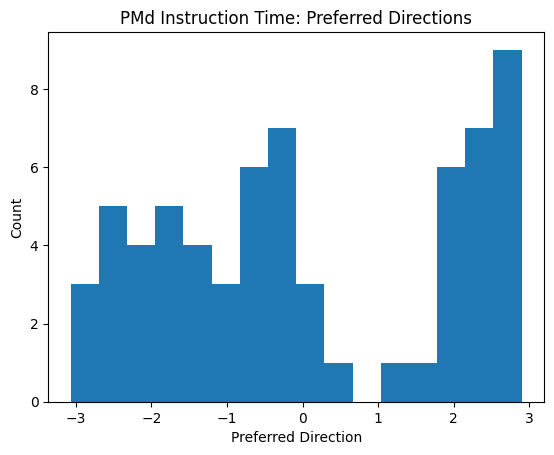

In [18]:
plt.hist(tune_pmd_instr['pd_angle'], bins=16)
plt.title("PMd Instruction Time: Preferred Directions")
plt.xlabel("Preferred Direction")
plt.ylabel("Count")
plt.show()

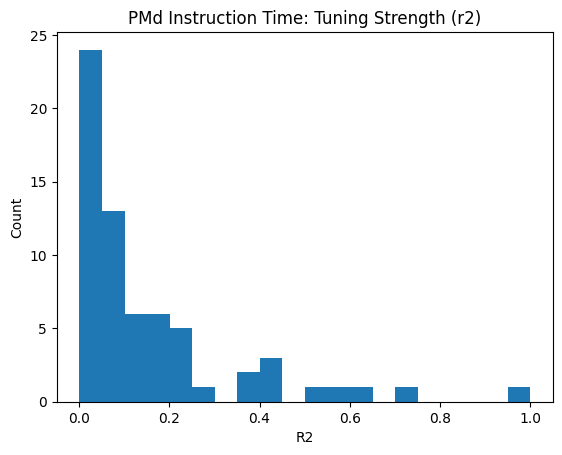

In [19]:
plt.hist(tune_pmd_instr['r2'], bins=20)
plt.title("PMd Instruction Time: Tuning Strength (r2)")
plt.xlabel("R2")
plt.ylabel("Count")
plt.show()

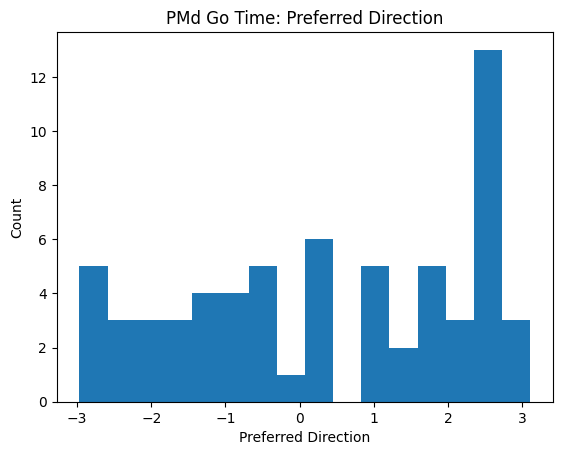

In [20]:
plt.hist(tune_pmd_go['pd_angle'], bins=16)
plt.title("PMd Go Time: Preferred Direction")
plt.xlabel("Preferred Direction")
plt.ylabel("Count")
plt.show()

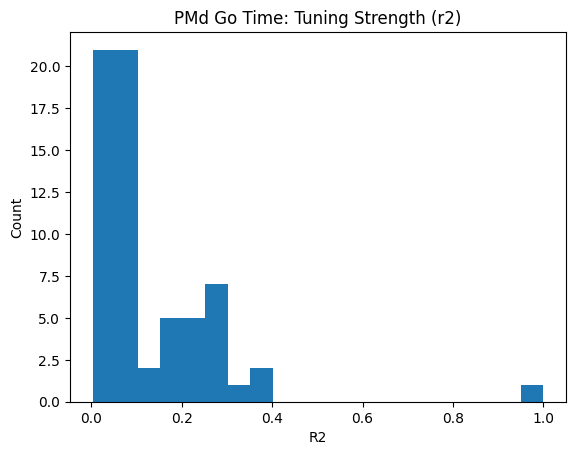

In [21]:
plt.hist(tune_pmd_go['r2'], bins=20)
plt.title("PMd Go Time: Tuning Strength (r2)")
plt.xlabel("R2")
plt.ylabel("Count")
plt.show()

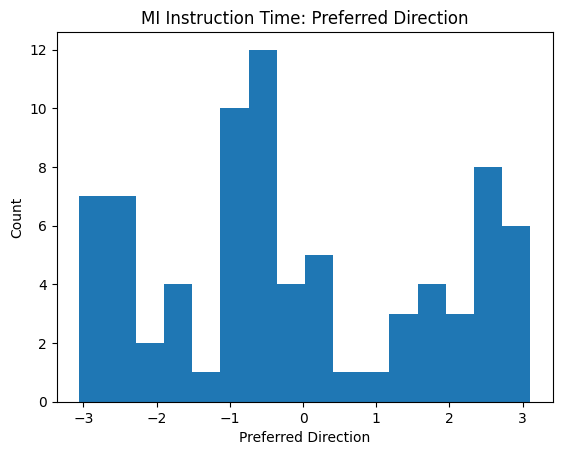

In [22]:
plt.hist(tune_mi_instr['pd_angle'], bins=16)
plt.title("MI Instruction Time: Preferred Direction")
plt.xlabel("Preferred Direction")
plt.ylabel("Count")
plt.show()

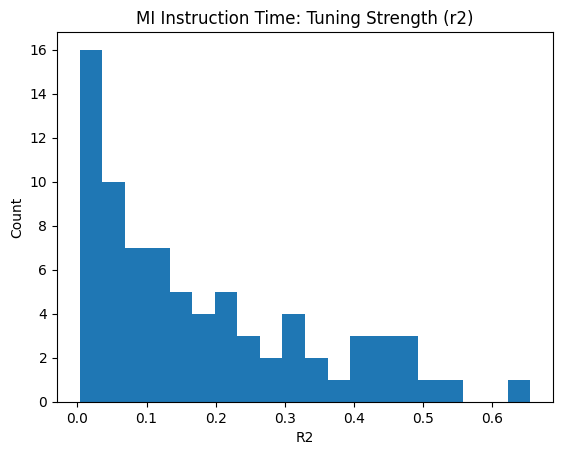

In [23]:
plt.hist(tune_mi_instr['r2'], bins=20)
plt.title("MI Instruction Time: Tuning Strength (r2)")
plt.xlabel("R2")
plt.ylabel("Count")
plt.show()

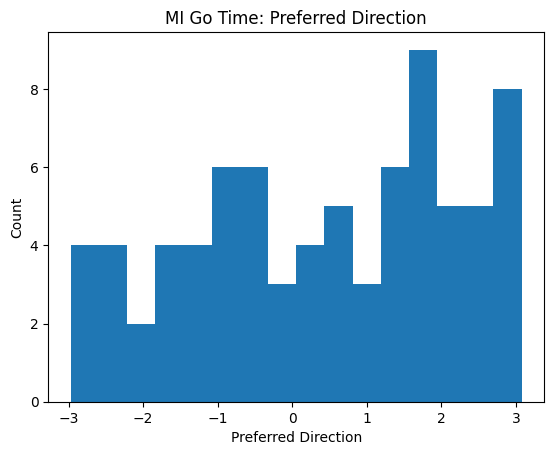

In [24]:
plt.hist(tune_mi_go['pd_angle'], bins=16)
plt.title("MI Go Time: Preferred Direction")
plt.xlabel("Preferred Direction")
plt.ylabel("Count")
plt.show()

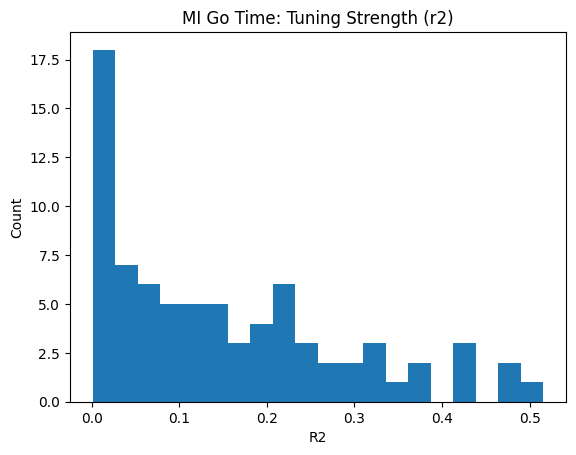

In [25]:
plt.hist(tune_mi_go['r2'], bins=20)
plt.title("MI Go Time: Tuning Strength (r2)")
plt.xlabel("R2")
plt.ylabel("Count")
plt.show()

In [26]:
tune_pmd_instr.sort_values("r2", ascending=False).head()

,cell_id,beta_x,beta_y,pd_angle,r2
23,23,0.000000,0.000000,0.000000,1.000000
1,1,-15.309086,9.981313,2.563822,0.743061
10,10,-6.422483,2.910985,2.716040,0.620100
48,48,-5.127317,2.146836,2.745066,0.558552
0,0,3.201712,-2.103313,-0.581234,0.549228


In [27]:
## Tuning curve plot for an individual neuron. (Mimicking Georgeopoulos' experiment.)

def plot_tuning_curve(df, cell_id, brain_area="PMd", window="instruction"):
    sub = df[(df['cell_id'] == cell_id) & (df['brain_area'] == brain_area) & (df['window'] == window)]
    
    ## Calculating mean firing rate per direction.
    means = sub.groupby("direction")["spike_count"].mean()
    
    ## Converting directions 1-8 -> angles 0-2pi
    angles = 2 * np.pi * (means.index - 1) / 8 
    
    ## Closing the circle for plotting.
    angles = np.append(angles, angles[0])
    mean_vals = np.append(means.values, means.values[0])
    
    ## Plot 
    figure = plt.figure(figsize=(6,6))
    ax = figure.add_subplot(111, polar=True)
    ax.plot(angles, mean_vals, marker="o")
    ax.set_title(f"Tuning Curve - Cell {cell_id} ({brain_area}, {window})")
    plt.show()

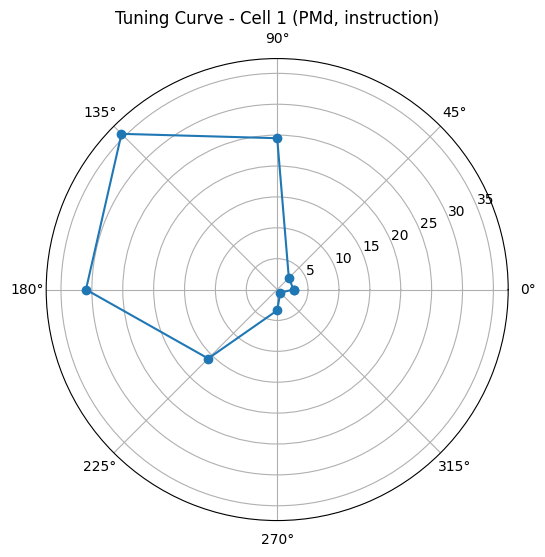

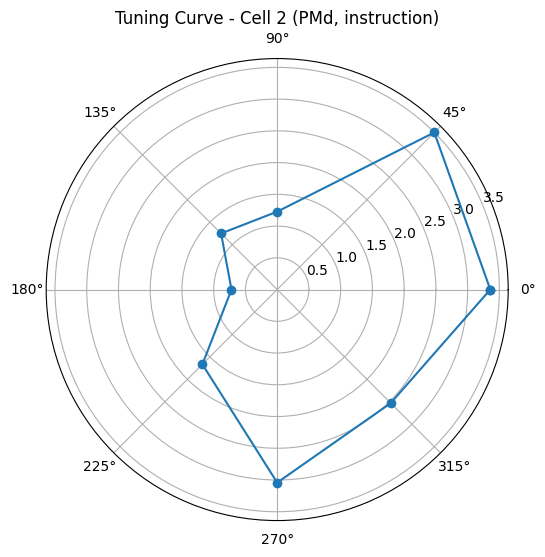

In [28]:
plot_tuning_curve(df, cell_id=1)
plot_tuning_curve(df, cell_id=2)

In [29]:
## Function to standardize neurons and run PCA. Returns PCA Object and transformed trial scores. 

def run_pca(matrix, n_components=10):
    scaler = StandardScaler()
    
    Xz = scaler.fit_transform(matrix.values) ## Z-Score of the neurons. 
    
    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(Xz)
    
    return pca, X_pca

    ## Running PCA for each condition.

In [30]:
pca_pmd_instr, x_pmd_instr = run_pca(m_pmd_instr)
pca_pmd_go, x_pmd_go = run_pca(m_pmd_go)

pca_mi_instr, x_mi_instr = run_pca(m_mi_instr)
pca_mi_go, x_mi_go = run_pca(m_mi_go)

In [31]:
def plot_variance(pca, title):
    plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o', label=title)
    plt.xlabel("Number of PCs")
    plt.ylabel("Cumulative Explained Variance")
    plt.title('Variance Explained')
    plt.ylim(0, 1)

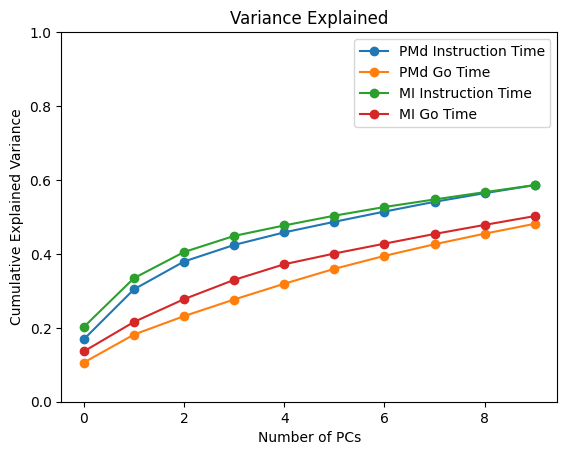

In [32]:
plot_variance(pca_pmd_instr, "PMd Instruction Time")
plot_variance(pca_pmd_go, "PMd Go Time")
plot_variance(pca_mi_instr, "MI Instruction Time")
plot_variance(pca_mi_go, "MI Go Time")

plt.legend()
plt.show()
plt.close()

In [33]:
def plot_pca_scatter(X_pca, directions, title):
    plt.figure(figsize=(6,6))
    
    for d in sorted(directions.unique()):
        idx = (directions == d)
        plt.scatter(X_pca[idx, 0], X_pca[idx, 1], label=f"Dir {d}", alpha=0.7)
    
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title(title)
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

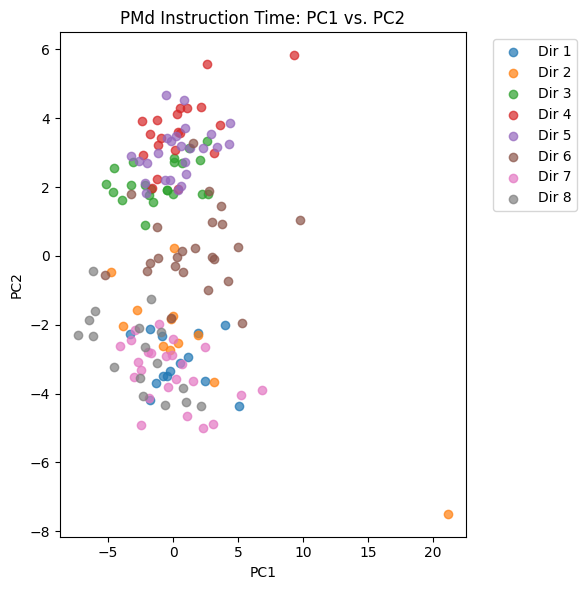

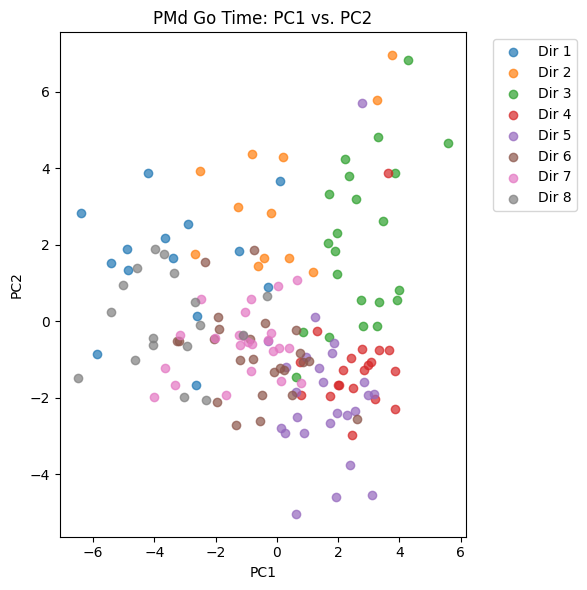

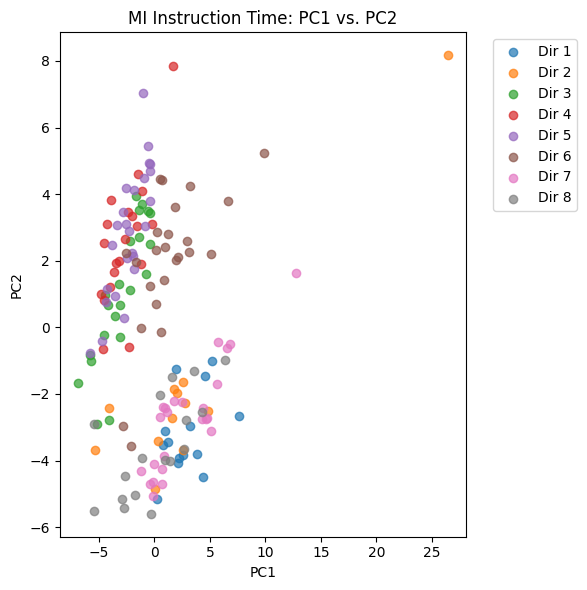

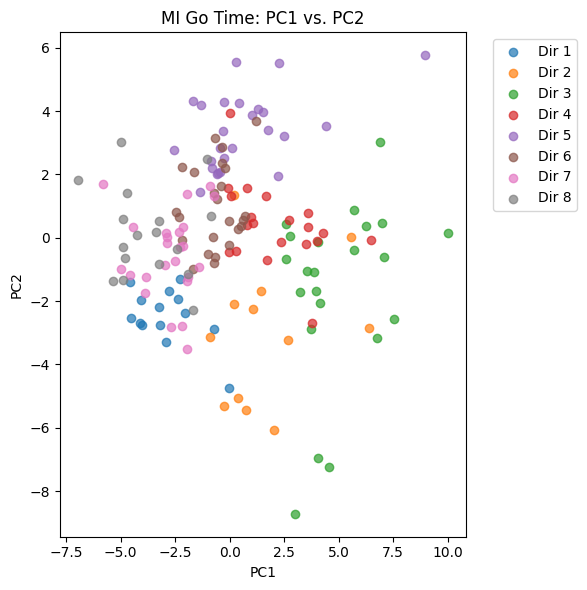

In [34]:
plot_pca_scatter(x_pmd_instr, y_pmd, "PMd Instruction Time: PC1 vs. PC2")
plot_pca_scatter(x_pmd_go, y_pmd, "PMd Go Time: PC1 vs. PC2")
plot_pca_scatter(x_mi_instr, y_mi, "MI Instruction Time: PC1 vs. PC2")
plot_pca_scatter(x_mi_go, y_mi, "MI Go Time: PC1 vs. PC2")

In [35]:
## Decoding direction through multinomial logistic regression with CV. Returns mean accuracy and std accuracy. 

def decode_direction(x, y, n_splits=5):
    x = np.asarray(x)
    y = np.asarray(y)
    
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=0)
    
    accuracies = []
    
    for train_idx, test_idx in cv.split(x, y):
        x_train, x_test = x[train_idx], x[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        model = Pipeline([("scaler", StandardScaler()), 
                          ("clf", LogisticRegression(
                              solver="lbfgs",
                              max_iter=500, 
                              C=1.0
                          ))
                         ])
        
        model.fit(x_train, y_train)
        y_pred = model.predict(x_test)
        acc = accuracy_score(y_test, y_pred)
        accuracies.append(acc)
    
    return np.mean(accuracies), np.std(accuracies)

In [36]:
acc_pmd_instr = decode_direction(m_pmd_instr.values, y_pmd)
acc_pmd_go = decode_direction(m_pmd_go.values, y_pmd)
acc_mi_instr = decode_direction(m_mi_instr.values, y_mi)
acc_mi_go = decode_direction(m_mi_go.values, y_mi)

In [37]:
print("PMd Instruction Time:", acc_pmd_instr)
print("PMd Go Time:", acc_pmd_go)
print("MI Instruction Time:", acc_mi_instr)
print("MI Go:", acc_mi_go)

PMd Instruction Time: (0.5768145161290322, 0.10746062306671006)
PMd Go Time: (0.671975806451613, 0.079988760104005)
MI Instruction Time: (0.6891129032258064, 0.07096258687288666)
MI Go: (0.753225806451613, 0.036643665135859)


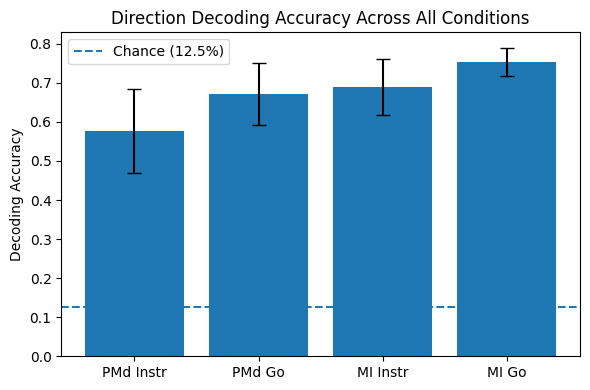

In [38]:
labels = ["PMd Instr", "PMd Go", "MI Instr", "MI Go"]

means = [
    acc_pmd_instr[0], 
    acc_pmd_go[0], 
    acc_mi_instr[0], 
    acc_mi_go[0]
]

stds = [
    acc_pmd_instr[1], 
    acc_pmd_go[1], 
    acc_mi_instr[1], 
    acc_mi_go[1]
]

plt.figure(figsize=(6, 4))
plt.bar(labels, means, yerr=stds, capsize=5)
plt.axhline(0.125, linestyle="--", label="Chance (12.5%)")
plt.ylabel("Decoding Accuracy")
plt.title("Direction Decoding Accuracy Across All Conditions")
plt.legend()
plt.tight_layout()
plt.show()